In [ ]:
# install kaggle API

import os
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria -p /content
import zipfile
import shutil
from pathlib import Path
CONTENT_DIR = Path("/content")
ZIP_PATH = CONTENT_DIR / "cell-images-for-detecting-malaria.zip"
extract_dir = CONTENT_DIR / "extracted"
if extract_dir.exists():
    shutil.rmtree(extract_dir)
extract_dir.mkdir()
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(extract_dir)

def find_dataset_root(root: Path):
    for path in root.rglob("*"):
        if not path.is_dir():
            continue
        subdirs = {d.name.lower() for d in path.iterdir() if d.is_dir()}
        if "parasitized" in subdirs and "uninfected" in subdirs:
            return path
    return None
dataset_root = find_dataset_root(extract_dir)
if dataset_root is None:
    raise FileNotFoundError("Could not find 'Parasitized' and 'Uninfected' folders in the ZIP.")
DATASET_DIR = CONTENT_DIR / "dataset"
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir()
for cls_name in ["Parasitized", "Uninfected"]:
    src = dataset_root / cls_name
    if not src.exists():
        src = dataset_root / cls_name.lower()
    if not src.exists():
        raise FileNotFoundError(f"Could not find folder for class '{cls_name}'.")
    shutil.copytree(src, DATASET_DIR / cls_name)
print("dataset structure:", list(os.listdir(DATASET_DIR)))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 94% 633M/675M [00:03<00:00, 147MB/s]
100% 675M/675M [00:03<00:00, 182MB/s]
dataset structure: ['Uninfected', 'Parasitized']


In [ ]:
# import required libraries

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import itertools
import tensorflow as tf
import sklearn.metrics as skm
tf.random.set_seed(42)
np.random.seed(42)
def show_images(images, labels, count=4):
    plt.figure(figsize=(6, 6))
    for i in range(count):
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Detected classes: ['Parasitized', 'Uninfected']

Image counts per class:
  Uninfected: 13780 images
  Parasitized: 13780 images


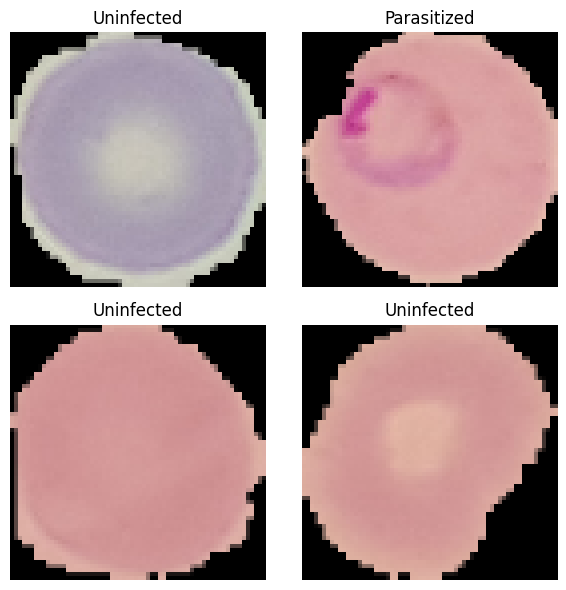

In [ ]:
# load dataset

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)
class_names = train_ds.class_names
print("Detected classes:", class_names)
print("\nImage counts per class:")
for folder in Path(DATASET_DIR).iterdir():
    if folder.is_dir():
        num_images = len(list(folder.glob("*.*")))
        print(f"  {folder.name}: {num_images} images")
for batch_images, batch_labels in train_ds.take(1):
    labels_str = [class_names[i] for i in batch_labels.numpy()]
    show_images(batch_images.numpy().astype("uint8"), labels_str, count=4)
    break

In [ ]:
# preprocessing and augmentation

AUTOTUNE = tf.data.AUTOTUNE
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),])
def prepare_dataset(ds, augment=False):
    # Normalize: uint8 [0,255] -> float32 [0,1]
    ds = ds.map(
        lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
        num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(
            lambda x, y: (augmentation_layer(x, training=True), y),
            num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)
train_ds_prep = prepare_dataset(train_ds, augment=True)
val_ds_prep   = prepare_dataset(val_ds, augment=False)

In [ ]:
# build and train CNN

from tensorflow.keras import layers, models
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPool2D(),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPool2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPool2D(),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")])
    return model
model = build_cnn_model(input_shape=IMG_SIZE + (3,), num_classes=len(class_names))
model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
EPOCHS = 8
history = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=EPOCHS)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,922 (1.09 MB)

 Trainable params: 285,922 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.6448 - loss: 0.5917 - val_accuracy: 0.9472 - val_loss: 0.1557
Epoch 2/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9528 - loss: 0.1529 - val_accuracy: 0.9516 - val_loss: 0.1401
Epoch 3/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 95ms/step - accuracy: 0.9577 - loss: 0.1339 - val_accuracy: 0.9521 - val_loss: 0.1399
Epoch 4/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9591 - loss: 0.1252 - val_accuracy: 0.9445 - val_loss: 0.1613
Epoch 5/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 95ms/step - accuracy: 0.9629 - loss: 0.1162 - val_accuracy: 0.9501 - val_loss: 0.1501
Epoch 6/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9647 - loss: 0.1051 - val_accuracy: 0.9419 - val_loss: 0.1667
Epoch 7/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.9666 - loss: 0.0978 - val_accuracy: 0.9521 - val_loss: 0.1456
Epoch 8/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.9704 - loss: 0.0850 - val_acc

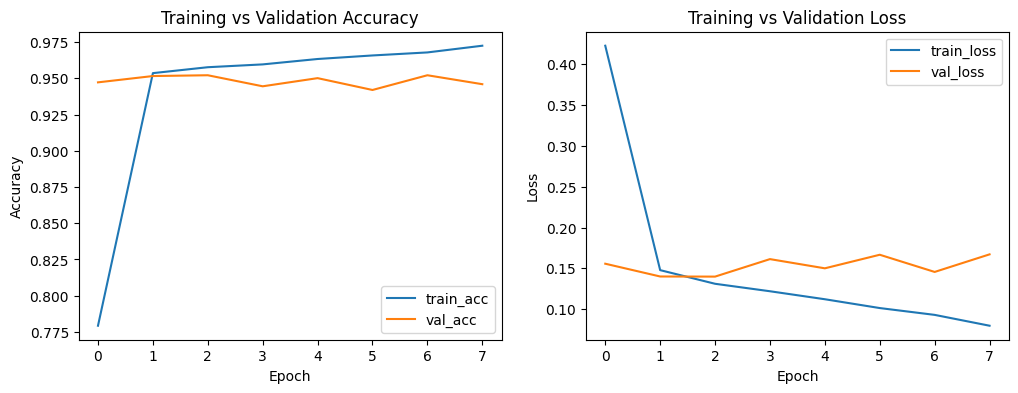

Classification report:
              precision    recall  f1-score   support

 Parasitized       0.99      0.90      0.94      2717
  Uninfected       0.91      0.99      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.95      0.95      0.95      5511
weighted avg       0.95      0.95      0.95      5511

Confusion Matrix:
 [[2456  261]
 [  37 2757]]


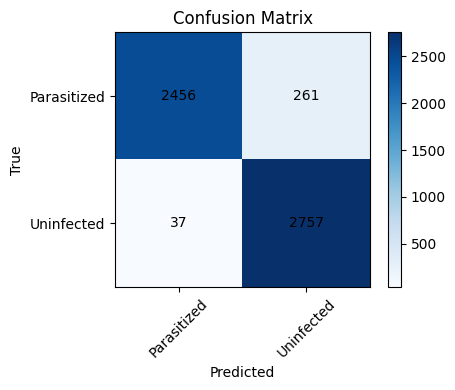

In [ ]:
# evaluation metrics and plots

def plot_training_curves(history):
    plt.figure(figsize=(12, 4))
    # accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    # loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()
plot_training_curves(history)
y_true, y_pred = [], []
for images, labels in val_ds_prep:
    probs = model.predict(images, verbose=0)
    preds = probs.argmax(axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
print("Classification report:")
print(skm.classification_report(y_true, y_pred, target_names=class_names))
cm = skm.confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
    #confusion matrix
def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(cm, class_names)

Using last conv layer for Grad-CAM: conv2d_2


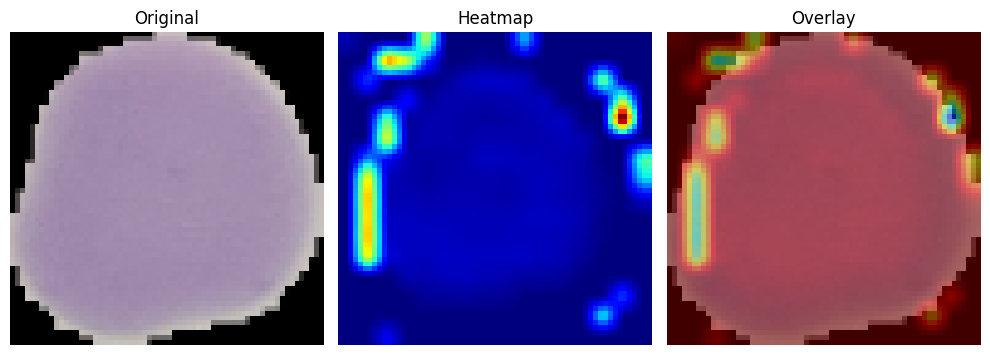

True label: Uninfected
Predicted label: Uninfected


In [ ]:
# heatmap of image

import cv2
for images, labels in val_ds.take(1):
    sample_img = images[0]
    sample_label = int(labels[0].numpy())
    break
img_norm = tf.cast(sample_img, tf.float32) / 255.0
img_batch = tf.expand_dims(img_norm, axis=0)
last_conv_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_name = layer.name
        break
if last_conv_name is None:
    raise RuntimeError("No Conv2D layer found in the model.")
print("Using last conv layer for Grad-CAM:", last_conv_name)
with tf.GradientTape() as tape:
    x = img_batch
    conv_outputs = None
    for layer in model.layers:
        try:
            x = layer(x, training=False)
        except TypeError:
            x = layer(x)
        if layer.name == last_conv_name:
            conv_outputs = x
    preds = x  # final output (1, num_classes)
    pred_index = tf.argmax(preds[0])
    loss = preds[:, pred_index]  # score for the predicted class
grads = tape.gradient(loss, conv_outputs)
if grads is None:
    raise RuntimeError("Gradients are None – check model/Grad-CAM graph.")
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0].numpy()
pooled_grads = pooled_grads.numpy()
for i in range(pooled_grads.shape[-1]):
    conv_outputs[:, :, i] *= pooled_grads[i]
heatmap = np.mean(conv_outputs, axis=-1)
heatmap = np.maximum(heatmap, 0)  # ReLU
if heatmap.max() != 0:
    heatmap /= heatmap.max()
else:
    heatmap = np.zeros_like(heatmap)
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
heatmap_rgb = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
orig = sample_img.numpy().astype("uint8")
overlay = cv2.addWeighted(heatmap_rgb, 0.5, orig, 0.5, 0)
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(orig); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("Heatmap"); plt.imshow(heatmap_resized, cmap="jet"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.tight_layout()
plt.show()
predicted_idx = int(tf.argmax(model(tf.expand_dims(img_norm, 0))[0]))
print("True label:", class_names[sample_label])
print("Predicted label:", class_names[predicted_idx])

In [ ]:
model.save("malaria_cnn.h5")
print("Model saved as malaria_cnn.h5")

print("""
Deployment:
- Convert to TensorFlow Lite for mobile use.
- Use Flask/FastAPI for web prediction.
- Input must be resized to 64×64, normalized to [0,1].
- Final diagnosis must be done by medical professionals.
""")

Model saved as malaria_cnn.h5

Deployment:
- Convert to TensorFlow Lite for mobile use.
- Use Flask/FastAPI for web prediction.
- Input must be resized to 64×64, normalized to [0,1].
- Final diagnosis must be done by medical professionals.



In [ ]:
# test any image

from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
model = tf.keras.models.load_model("/content/malaria_cnn.h5")
IMG_SIZE = (64, 64)
uploaded = files.upload()
file = list(uploaded.keys())[0]
img = load_img(file, target_size=IMG_SIZE)
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
pred = model.predict(img_array)[0][0]
label = "Parasitized" if pred >= 0.5 else "Uninfected"
print("\nPrediction:", label)
print("Raw model output:", float(pred))

Saving C33P1thinF_IMG_20150619_115740a_cell_162.png to C33P1thinF_IMG_20150619_115740a_cell_162.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Prediction: Parasitized
Raw model output: 0.9999570846557617
